# Handling Noisy Data

When handling real world data, it would often be contaminated with noise. Numerical differentiation via finite difference is only suited for clean and smooth data. Any noise or discontinuity would be amplified. In this tutorial, we will
1. Demonstrate the effects of noise on numerically differentiated data
2. Present methods for data smoothing
3. Demonstrate how to differentiate noisy data using [total variation regularization differentiation](https://onlinelibrary.wiley.com/doi/epdf/10.5402/2011/164564).

Whilst the methods showcased in this tutorial can mitigate the effects of low level noise, the prime method for handling noisy data is to use [weak form SINDy](./1-7%20Weak%20Form/).

In [1]:
# Import all required libraries

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from scipy import signal
import warnings

from sindy.ivp_solvers import rk4
from sindy.utils import set_seed
from sindy.odes import generate_ode_data, lorenz, add_gauss_noise
from sindy.plot_utils import \
    init_plt_format, \
    visualize_ode_3d

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Finite Difference and Noise

Noisy data are characterized by contamination with spurious signals. When numerically differentiated, noise signal with high frequencies are always amplified. Let us use a motivating example of

$$ y = f(x) + \epsilon(\sigma), $$

where $\epsilon$ is an additive Gaussian noise component with a standard deviation of $\sigma$. Let us specify $\epsilon$ as a single sine wave with frequency $\omega_{\text{noise}}$ and amplitude $A$ such that

$$
\begin{aligned}
    y &= f(x) + A \sin(\omega_{\text{noise}} x), \\
    \frac{dy}{dx} &= f'(x) + A \omega_{\text{noise}} \cos(\omega_{\text{noise}} x), \\
    \frac{d^ny}{dx^n} &= f^{(n)}(x) + 
    \begin{cases} 
        (-1)^{\frac{n}{2}} A \omega_{\text{noise}}^n \sin(\omega_{\text{noise}} x) & \text{for } n \text{ even} \\ 
        (-1)^{\frac{n-1}{2}} A \omega_{\text{noise}}^n \cos(\omega_{\text{noise}} x) & \text{for } n \text{ odd} 
    \end{cases}
\end{aligned}
$$

Therefore, the higher the frequency, the larger the amplitude of the noise component in the derivative. It can be further amplified by the use of higher order derivatives.

To define the level of our noise, we will follow the definition set out by [(Messenger and Bortz, 2021)](https://epubs.siam.org/doi/abs/10.1137/20M1343166) where the standard deviation $\sigma$ of the Gaussiaan noise is defined as a function of a noise ratio $\sigma_{\text{NR}}$ such that

$$ \sigma = \sigma_{\text{NR}}\frac{||\mathbf{x}||_F}{\sqrt{MN}}, $$

where $\mathbf{x} \in \mathbb{R}^{M \times N}$. Let us visualize the effects of noise on differentiation.

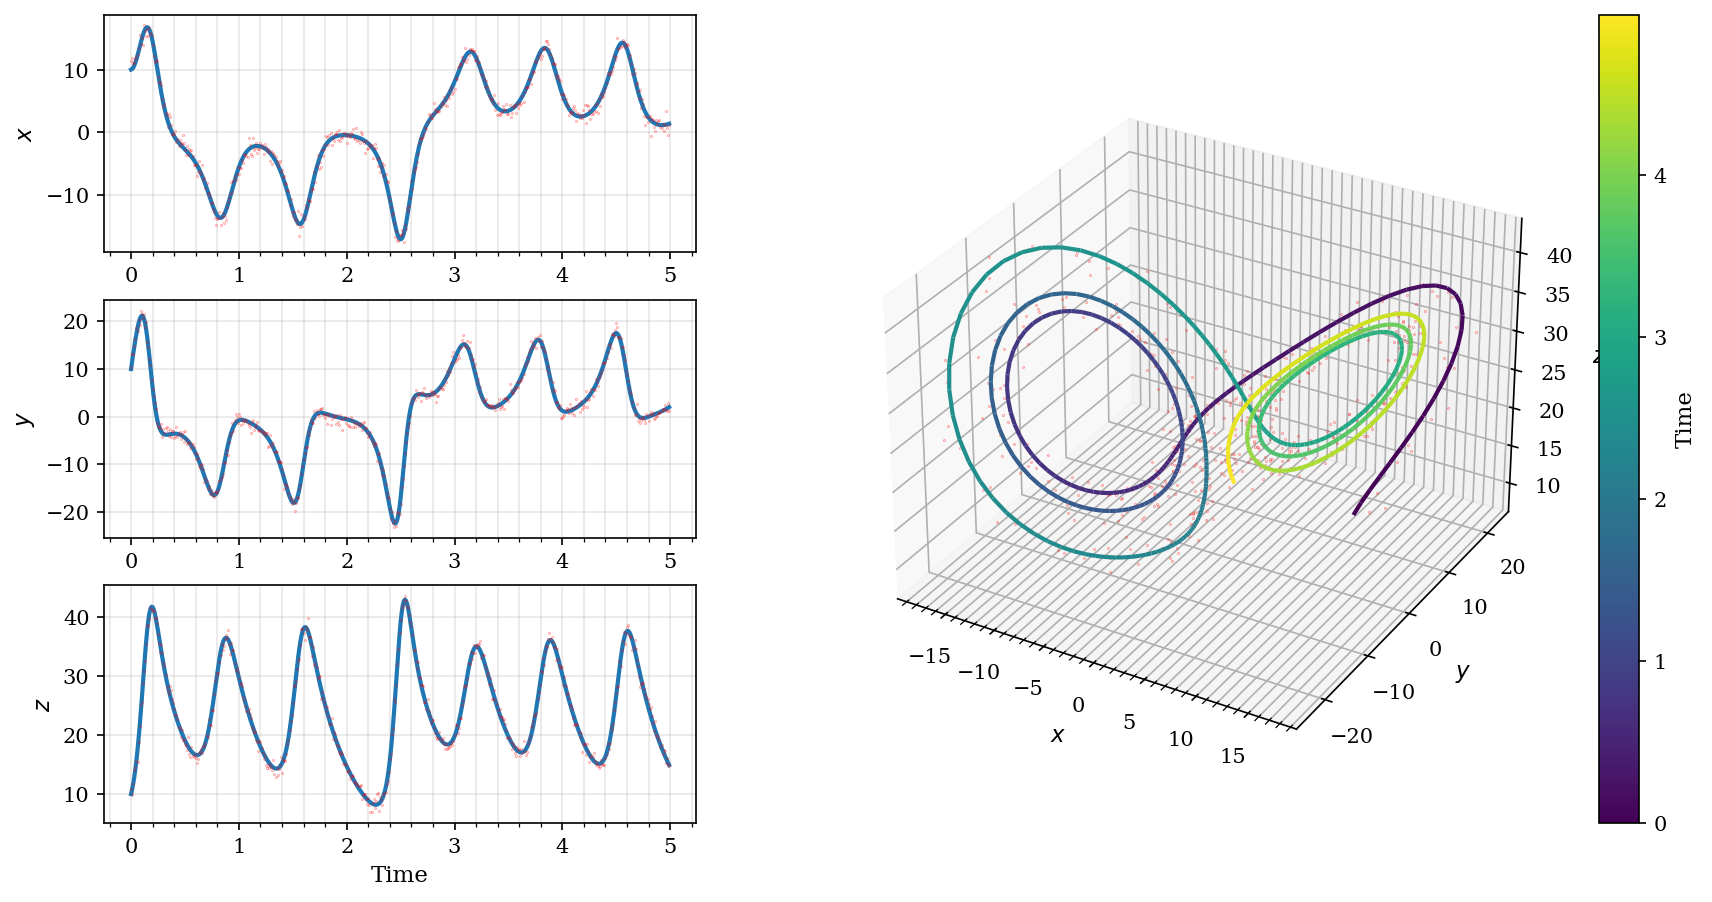

In [2]:
noise_ratio = 0.05

t, x, x_noisy = generate_ode_data(
    500, 0.01, np.array([10, 10, 10]),
    ode=lorenz, ode_params=[10, 8/3, 28],
    ivp_solver=rk4, noise_ratios=[noise_ratio]
)
x_noisy = x_noisy[0]
visualize_ode_3d(x, t, x_noisy)

We will differentiate both the clean data and noisy data (shown as red dots) using 4th order finite difference method.

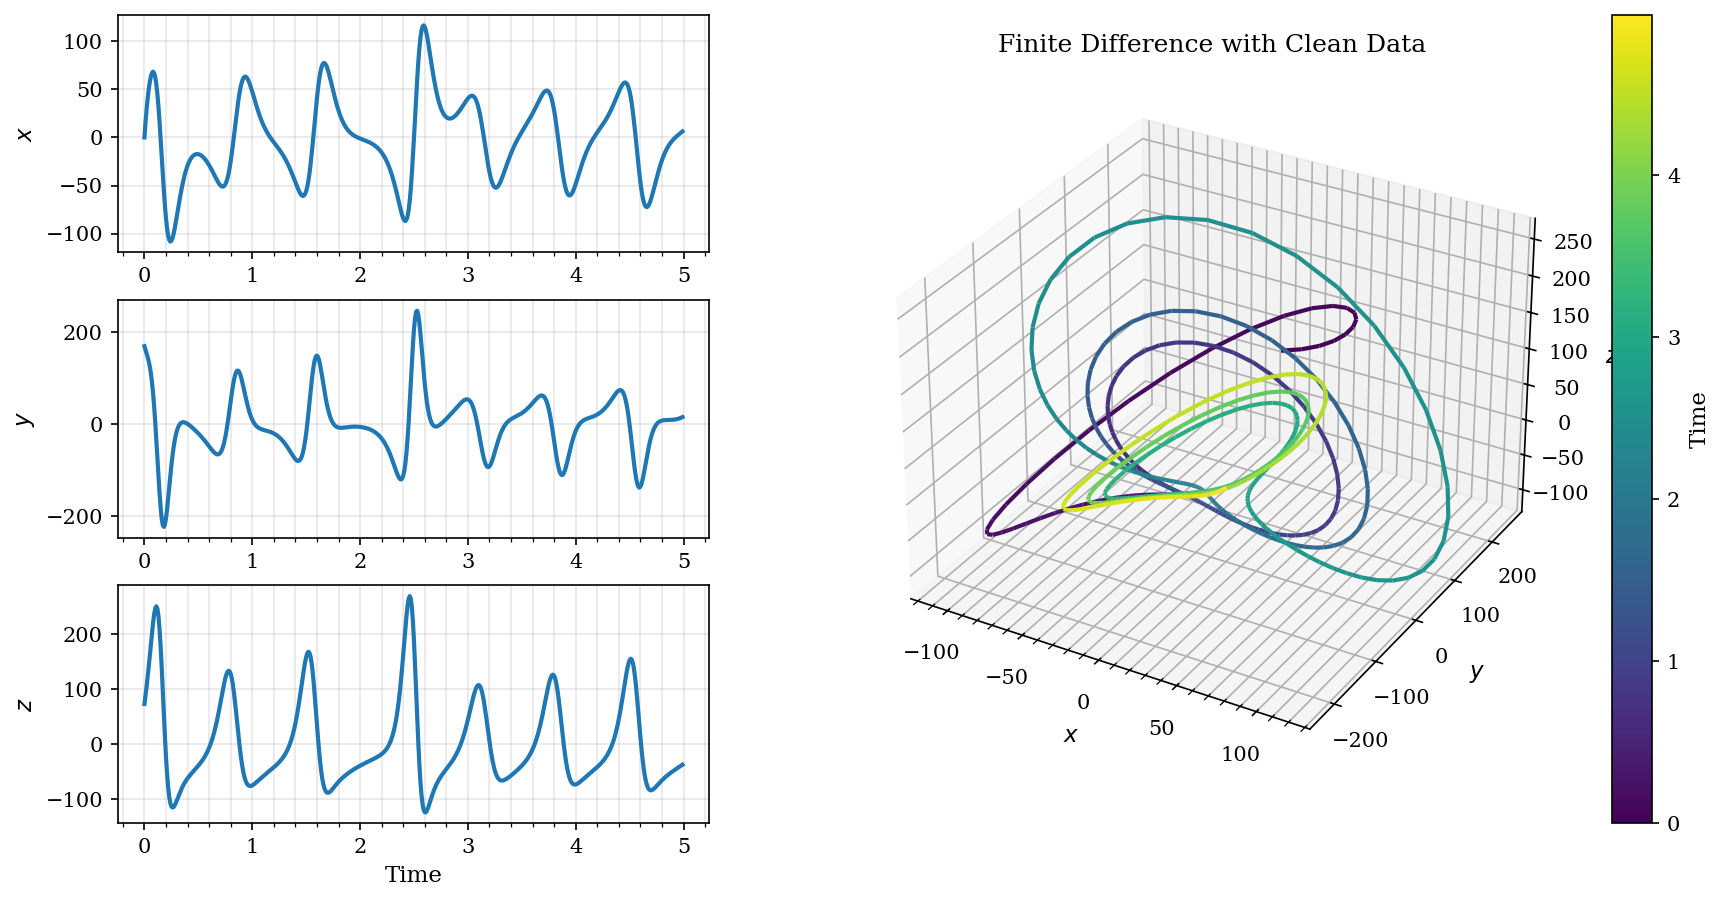

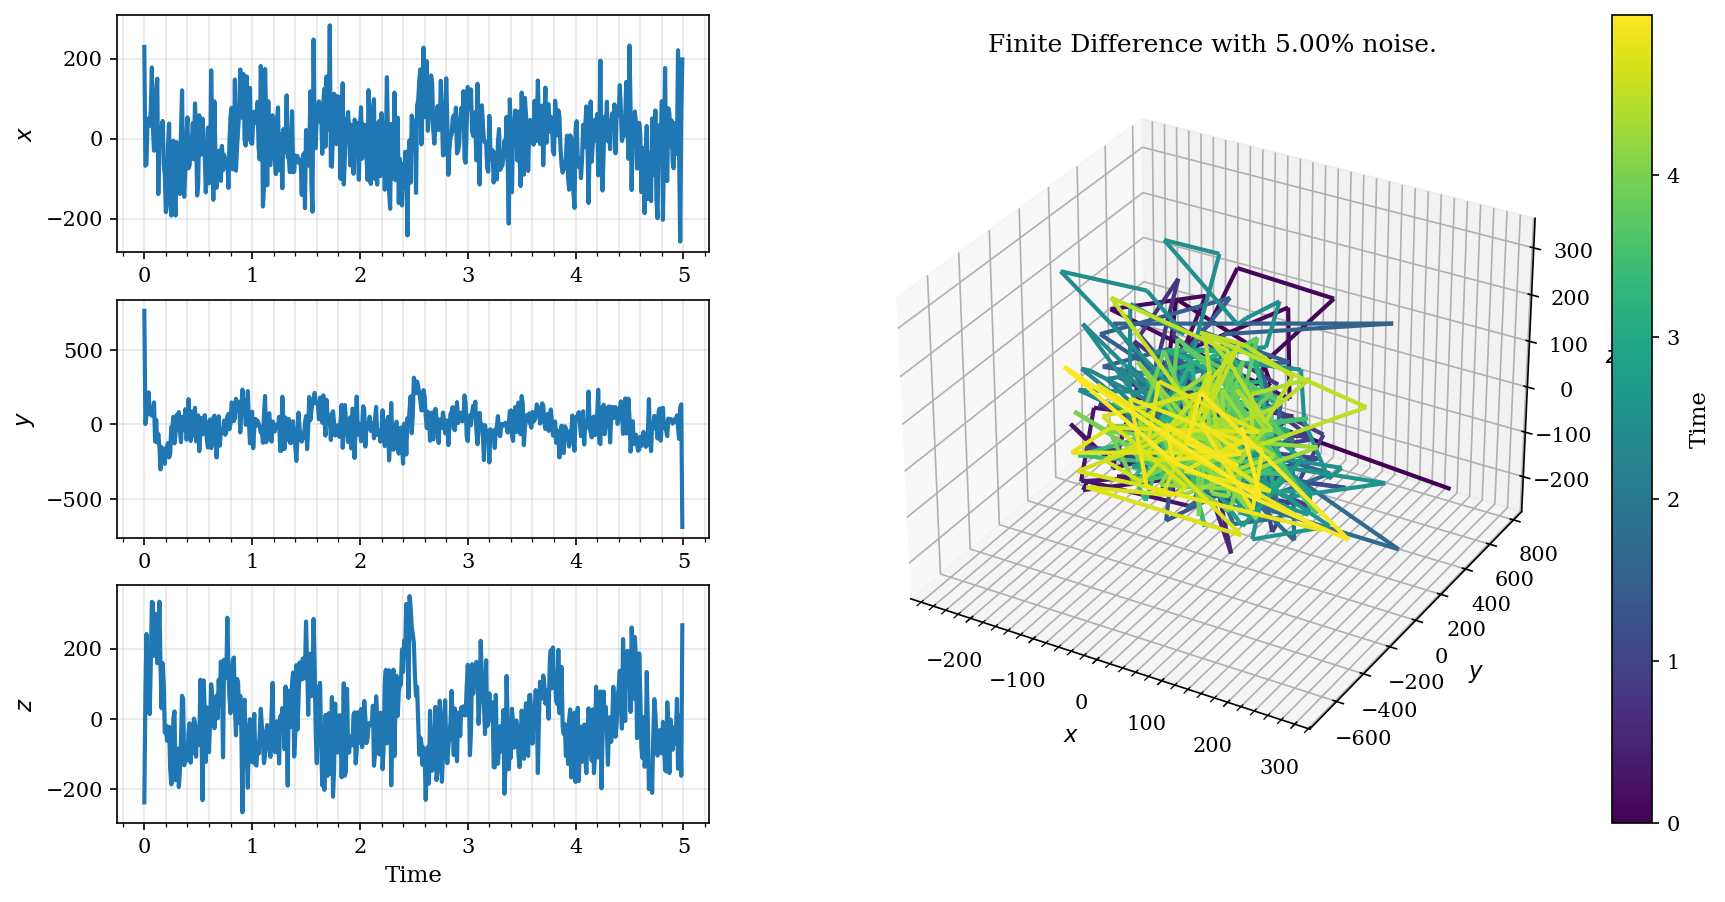

In [3]:
xdot = ps.FiniteDifference(4)._differentiate(x,t)
visualize_ode_3d(xdot, t, title="Finite Difference with Clean Data")

xdot_noisy = ps.FiniteDifference(4)._differentiate(x_noisy, t)
visualize_ode_3d(
    xdot_noisy, t,
    title=f"Finite Difference with {noise_ratio*100:.2f}% noise."
)

It is quite clear from above that the noisy derivative contains very little useful information and is completely corrupted by noise. Therefore, we must employ data smoothing methods to mitigate the effects of noise.


# Data Smoothing Methods

## Savitzky-Golay Filter

We will first introduce the [Savitzky-Golay (Savgol) filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter) which runs a sliding window through the dataset via convolution. It then fits a dth order polynomial to the data within the window to obtain the new central point within the window. The hyperparameters dth order of the polynomial and window size must be tuned to balance the smoothing strength. Let us filter the data with scipy's `savgol_filter` which is the same filter employed in PySINDy's `SmoothedFiniteDifference` class. Note that `SmoothedFiniteDifference` defaults to a window size of 11 and 3rd order polynomial.

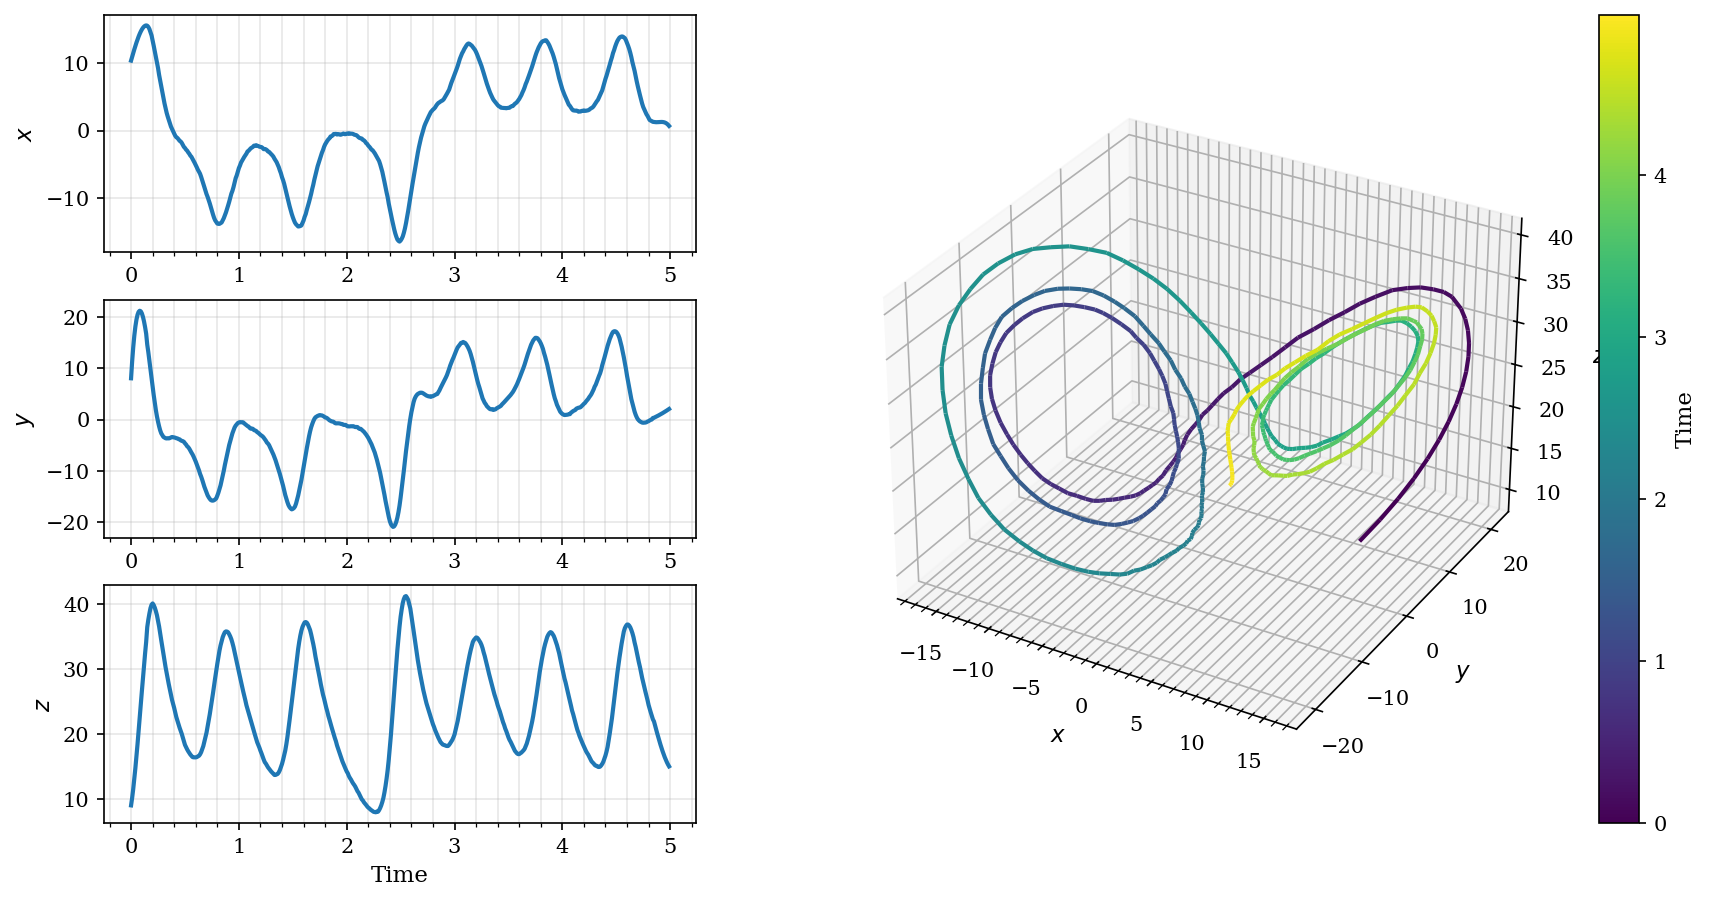

In [4]:
x_smoothed_sg = signal.savgol_filter(x_noisy, 30, 3, axis=0)
visualize_ode_3d(x_smoothed_sg, t)

As shown above, the original system can be recovered. Typically, larger window sizes and lower polynomial degree result in stronger smoothing effects. The optimal hyperparameters to use depends on the data, where one must smoothen out high frequency noise but strive to keep the true dynamics intact.

## Butterworth Filter

The [Butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter) is a filter that filters the signal using a low-pass filter (high-pass and band-passes are also possible). A low-pass filter convolves the signal with a transfer function that is designed to attenuate frequencies beyond a cutoff frequency. The low-pass function is shown below, parameterized by the cutoff frequency and the filter order. The cutoff frequency determines the frequency at which attenuation begins, whilst higher filter order further increases the attenuation strength. However, the higher the filter order, the larger the phase shift.

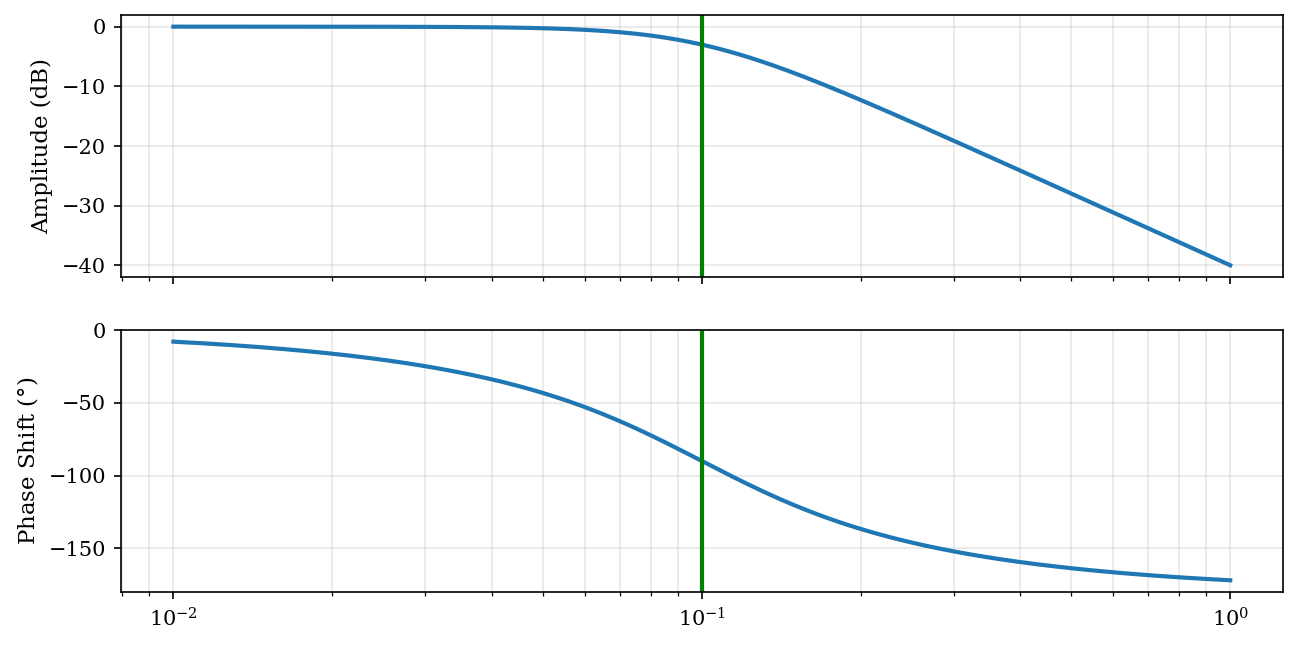

In [ ]:
filt_order = 2
cutoff_freq = 0.1

b, a = signal.butter(filt_order, cutoff_freq, analog=True)
w, h = signal.freqs(b, a)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10,5))

axs[0].semilogx(w, 20*np.log10(abs(h)))
axs[0].set_ylabel('Amplitude (dB)')
axs[0].axvline(cutoff_freq, color='green')

axs[1].semilogx(w, np.degrees(np.unwrap(np.angle(h))))
axs[1].set_ylabel(r'Phase Shift ($\degree$)')
axs[1].axvline(cutoff_freq, color='green');

To design a filter for our data, it is useful to first perform a fast Fourier transform (FFT) to analyze the dominant frequencies present in the dataset. Noise signals are typically high in frequency with relatively lower amplitudes (assuming reasonable levels of signal to noise ratio). We may set our cutoff frequency at the point which the signal begins to taper off in amplitude.

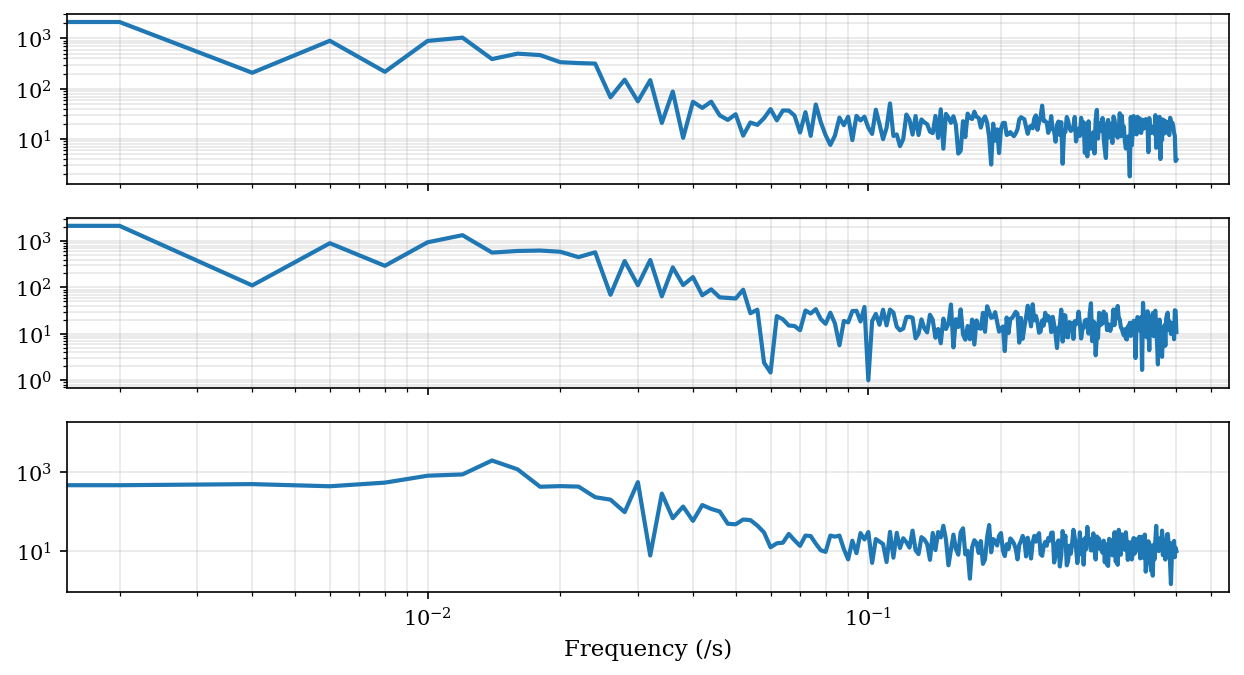

In [6]:
x_hat = np.fft.rfft(x_noisy, axis=0)
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10,5))
for idx in range(3):
    axs[idx].plot(np.fft.rfftfreq(x.shape[0]), np.abs(x_hat[:,idx]))
    axs[idx].set_xscale('log')
    axs[idx].set_yscale('log')
    axs[idx].minorticks_on()
axs[-1].set_xlabel('Frequency (/s)');

From the above plot, let us set a cutoff frequency of 0.1. We will use a first order filter, and increase it if necessary.

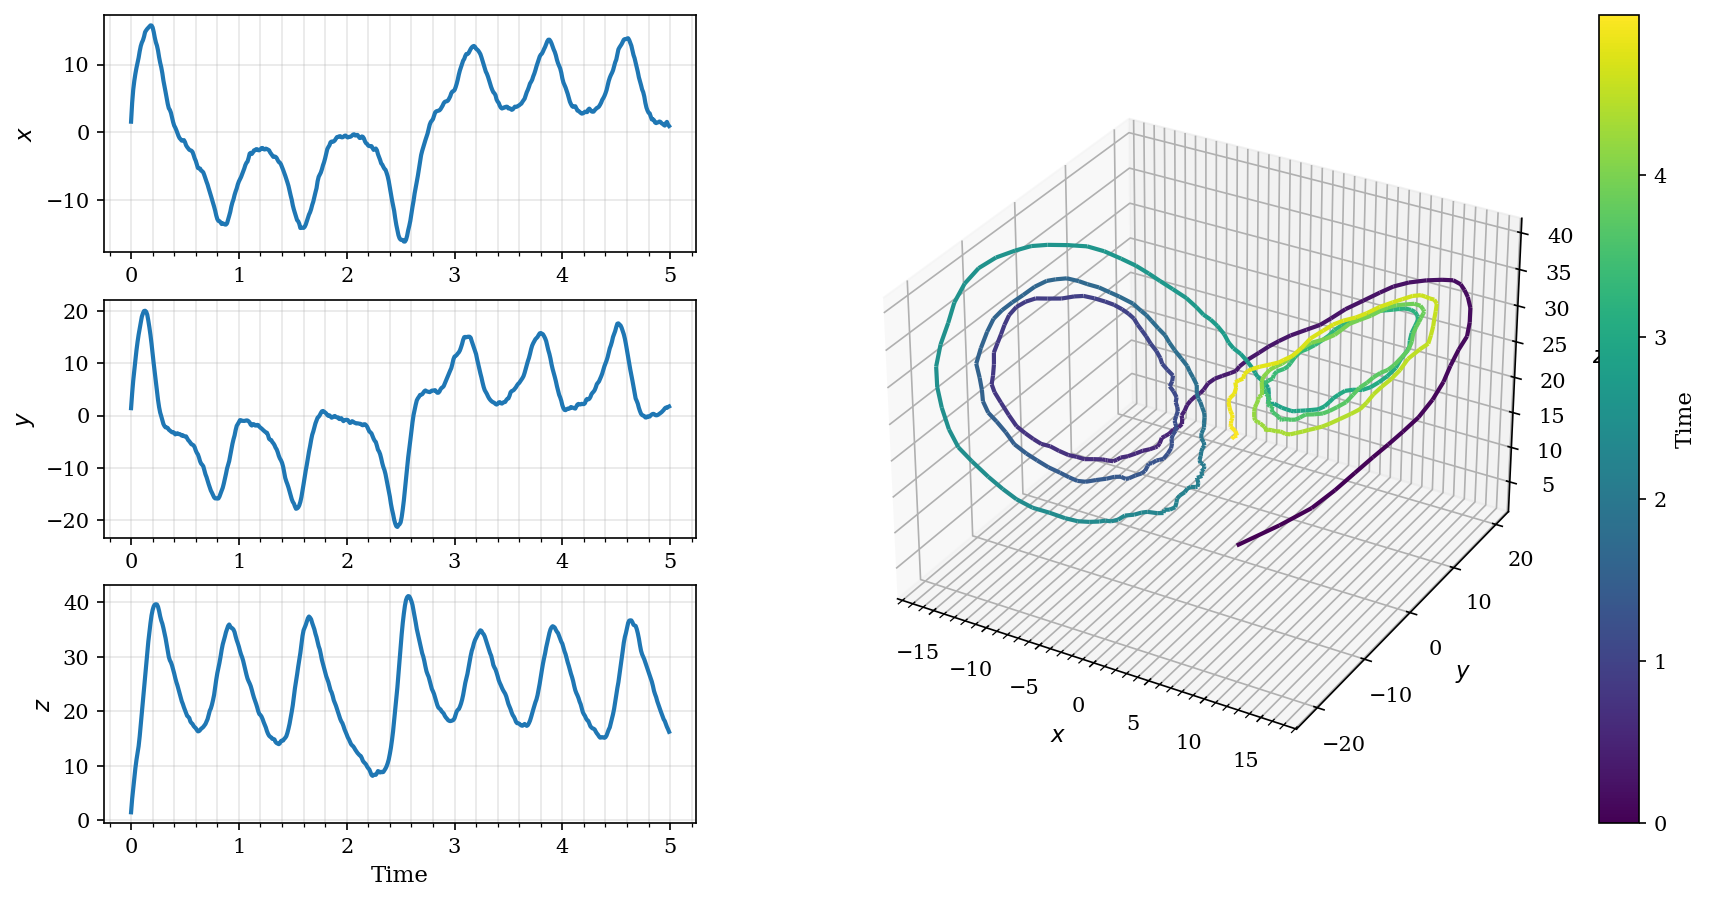

In [7]:
filt_order = 1
cutoff_freq = 0.1

sos = signal.butter(filt_order, cutoff_freq, output='sos')
x_smoothed_but = signal.sosfilt(sos, x_noisy, axis=0)
visualize_ode_3d(x_smoothed_but, t)

As shown above, we can recover the original system. Alternatively, a brick-wall filter, which is an idealized low-pass filter, may also be used. The filter truncates off high frequency signals by setting the high frequency components to zero. Furthermore, due to the sharp truncation of high frequency components, this may result in ringing effects if sampling time is too high or the window is too small. This also affects Butterworth filter. The use of [windowing functions](https://en.wikipedia.org/wiki/Window_function) such as a Hanning window may be used to mitigate it.

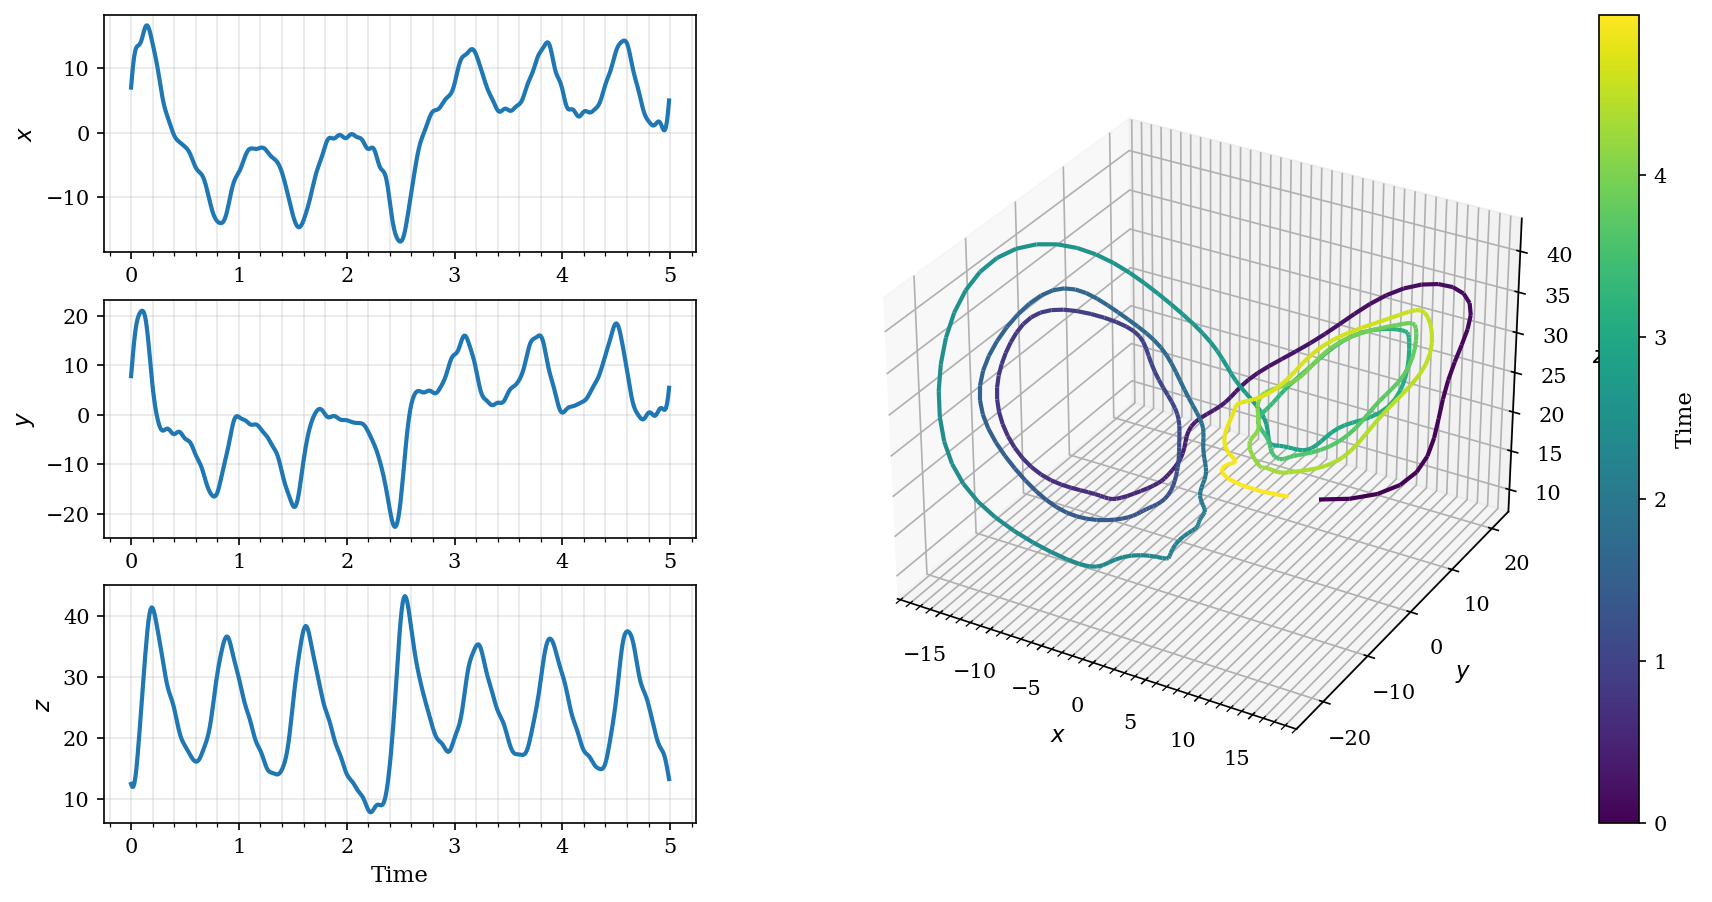

In [8]:
freq = np.fft.rfftfreq(x.shape[0])
cutoff_idx = np.argmin(np.abs(freq - cutoff_freq))

x_hat_truncated = x_hat.copy()
x_hat_truncated[cutoff_idx:, :] = 0.0
x_smoothed_brick = np.fft.irfft(x_hat_truncated, axis=0)

visualize_ode_3d(x_smoothed_brick, t)

## Comparing Data Smoothing Methods

Carrying out numerical differentiation on smoothed data produces significantly better results than directly differentiating the noisy dataset as shown before. Let us now compare the two methods presented with its derivative computed from clean data.

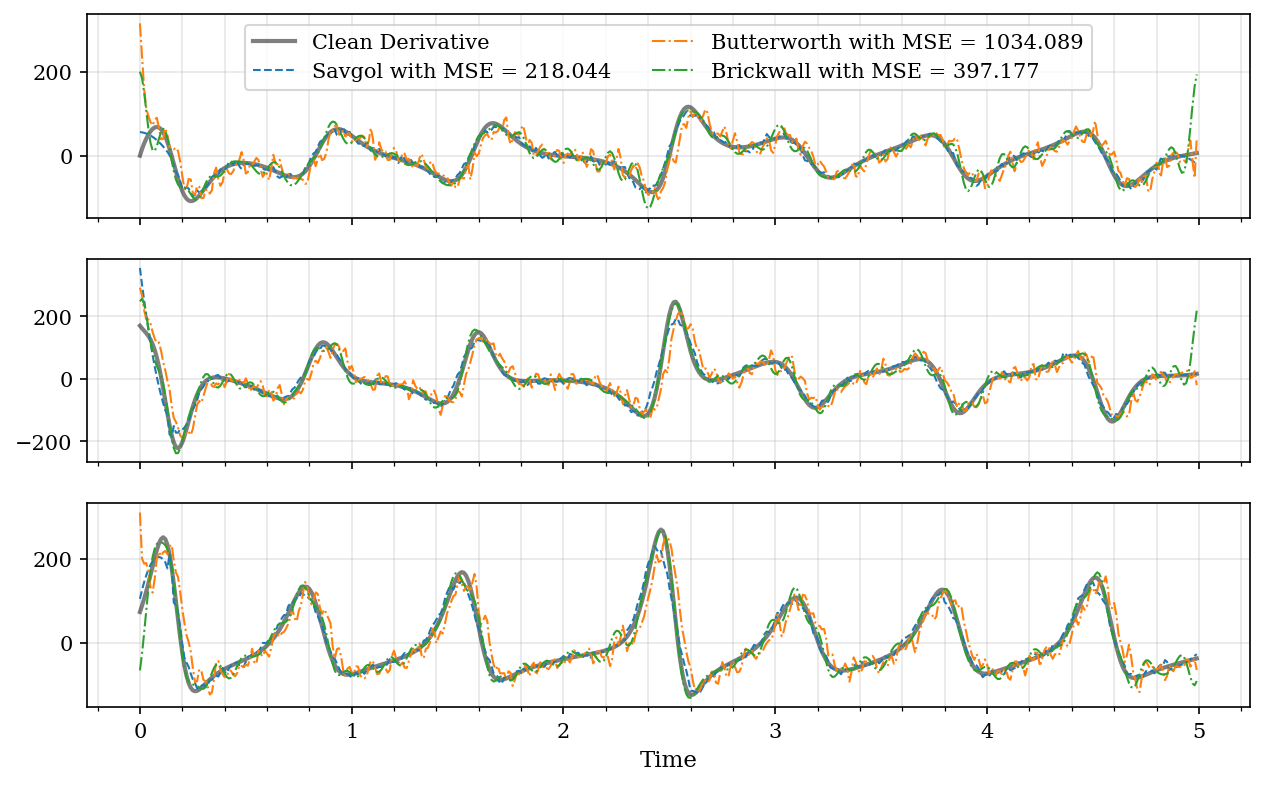

In [9]:
xdot_sg = ps.FiniteDifference(4)._differentiate(x_smoothed_sg, t)
xdot_but = ps.FiniteDifference(4)._differentiate(x_smoothed_but, t)
xdot_brick = ps.FiniteDifference(4)._differentiate(x_smoothed_brick, t)

sg_mse = np.mean((xdot_sg - xdot)**2)
but_mse = np.mean((xdot_but - xdot)**2)
brick_mse = np.mean((xdot_brick - xdot)**2)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10,6))

for idx in range(3):

    axs[idx].plot(
        t, xdot[:,idx], 'k',
        label='Clean Derivative', alpha=0.5
    )
    axs[idx].plot(
        t, xdot_sg[:,idx], '--',
        label=f'Savgol with MSE = {sg_mse:.3f}', linewidth=1
    )
    axs[idx].plot(
        t, xdot_but[:,idx], '-.',
        label=f'Butterworth with MSE = {but_mse:.3f}', linewidth=1
    )
    axs[idx].plot(
        t, xdot_brick[:,idx], '-.',
        label=f'Brickwall with MSE = {brick_mse:.3f}', linewidth=1
    )
    
axs[-1].set_xlabel('Time')
axs[0].legend(loc='upper center', ncol=2);

When compared to the true derivative, the phase delay from the Butterworth filter becomes obvious. Therefore, Savgol and Brickwall filters are the preferred methods of data smoothing.


# Total Variation Regularized Derivative

The [total variation regularized (TVR) derivative](https://onlinelibrary.wiley.com/doi/epdf/10.5402/2011/164564) formulates the problem of numerical differentiation into an optimization problem such that

$$ u^\star = \underset{u}{\arg\!\min} \left( \alpha \int^L_0 |u'| + \frac{1}{2} \int^L_0 | Au - x |^2 \right), $$

where $Au(x) = \int^x_0 u$ is an integral operator. The motivation is to minimise the difference between the integral of a candidate solution $u$, which represents the differentiated data, with the actual original data $x$. Numerical integration does not amplify noise like numerical differentiation does. Whilst regularized by the total variation derivative using the hyperparameter $\alpha.$ As the total variation of a variable is discontinuous, there is no convex solution. We adapt the proposed TVR derivative method from [(Chartrand, 2011)](https://onlinelibrary.wiley.com/doi/epdf/10.5402/2011/164564) which employs a lagged diffusivity algorithm to construct a TVR differentiator.

In [ ]:
def tvr(
        x: np.ndarray, t: np.ndarray,
        alpha: float = 1e-3, eps: float = 1e-6,
        tol: float = 1e-6, iter_max: int = 2000
) -> np.ndarray:
    """
    Adapted from (Chartrand, 2011) which solves the optimization problem with
    lagged diffusivity algorithm.

    Args:
        x (np.ndarray): State data matrix.
        t (np.ndarray): Time vector.
        alpha (float, optional): Regularization parameter. Defaults to 1e-3.
        eps (float, optional): Diffusivity parameter. Defaults to 1e-6.
        tol (float, optional): Convergence tolerance. Defaults to 1e-6.
        iter_max (int, optional): Maximum iterations. Defaults to 2000.

    Returns:
        np.ndarray: Differentiated data matrix.
    """
    
    # Shape check
    if x.ndim == 1:
        x = x[:, None]

    # Reset initial condition to 0
    x -= x[0]

    # Get data dimensions
    m = x.shape[0]
    n = x.shape[1]

    # Get time step
    dt = np.mean(np.diff(t))

    # Get integration matrix (trapezoidal rule)
    A = np.tril(np.ones((m, m))) * dt
    A -= np.diag(np.ones(m) * dt/2)
    A[:,0] -= dt/2.0

    # Get derivative matrix (first order forward)
    D = np.zeros((m, m))
    rows, cols = np.diag_indices(m)
    D[rows[:-1], cols[:-1] + 1] = 1.0 / dt
    D[rows, cols] = -1.0 / dt

    # Apply first order backward for boundary term
    D[-1, -1] =  1.0 / dt
    D[-1, -2] = -1.0 / dt

    # Initialise xdot with the derivative operator
    xdot = np.empty(x.shape)
    for idx in range(n):
        xdot[:, idx] = D @ x[:, idx]

    # Pre-compute A^T @ A
    AtA = A.T @ A

    # Solve the iterative Newton-Raphson method
    for idx in range(n):

        for iterIdx in range(iter_max):

            # Compute intermediate variables
            Q = np.diag(1/np.sqrt((D @ xdot[:,idx])**2 + eps))
            L = D.T @ Q @ D

            # Compute the gradient
            g = AtA @ xdot[:, idx] - A.T @ x[:, idx] + alpha * L @ xdot[:, idx]

            # Compute the Hessian using lagged approximation
            H = AtA + alpha * L

            # Compute the difference between steps
            s = np.linalg.solve(H, -g)

            # Update derivative value
            xdot[:, idx] += s

            # Check this iteration has converged
            if np.linalg.norm(s) < tol:
                break
            
            # Warn if iteration limit is exceeded
            if (iterIdx + 1) == iter_max:
                warnings.warn(f'Iteration limit exceeded for state {idx+1:d}.')

    return xdot

Let us apply TVR derivative and compare it with our previous data smoothing method.

/var/folders/j3/qn_kk08j1hqcw5jlph49xzch0000gp/T/ipykernel_44845/3818603155.py:86: UserWarning: Iteration limit exceeded for state 1.
  warnings.warn(f'Iteration limit exceeded for state {idx+1:d}.')
/var/folders/j3/qn_kk08j1hqcw5jlph49xzch0000gp/T/ipykernel_44845/3818603155.py:86: UserWarning: Iteration limit exceeded for state 2.
  warnings.warn(f'Iteration limit exceeded for state {idx+1:d}.')
/var/folders/j3/qn_kk08j1hqcw5jlph49xzch0000gp/T/ipykernel_44845/3818603155.py:86: UserWarning: Iteration limit exceeded for state 3.
  warnings.warn(f'Iteration limit exceeded for state {idx+1:d}.')


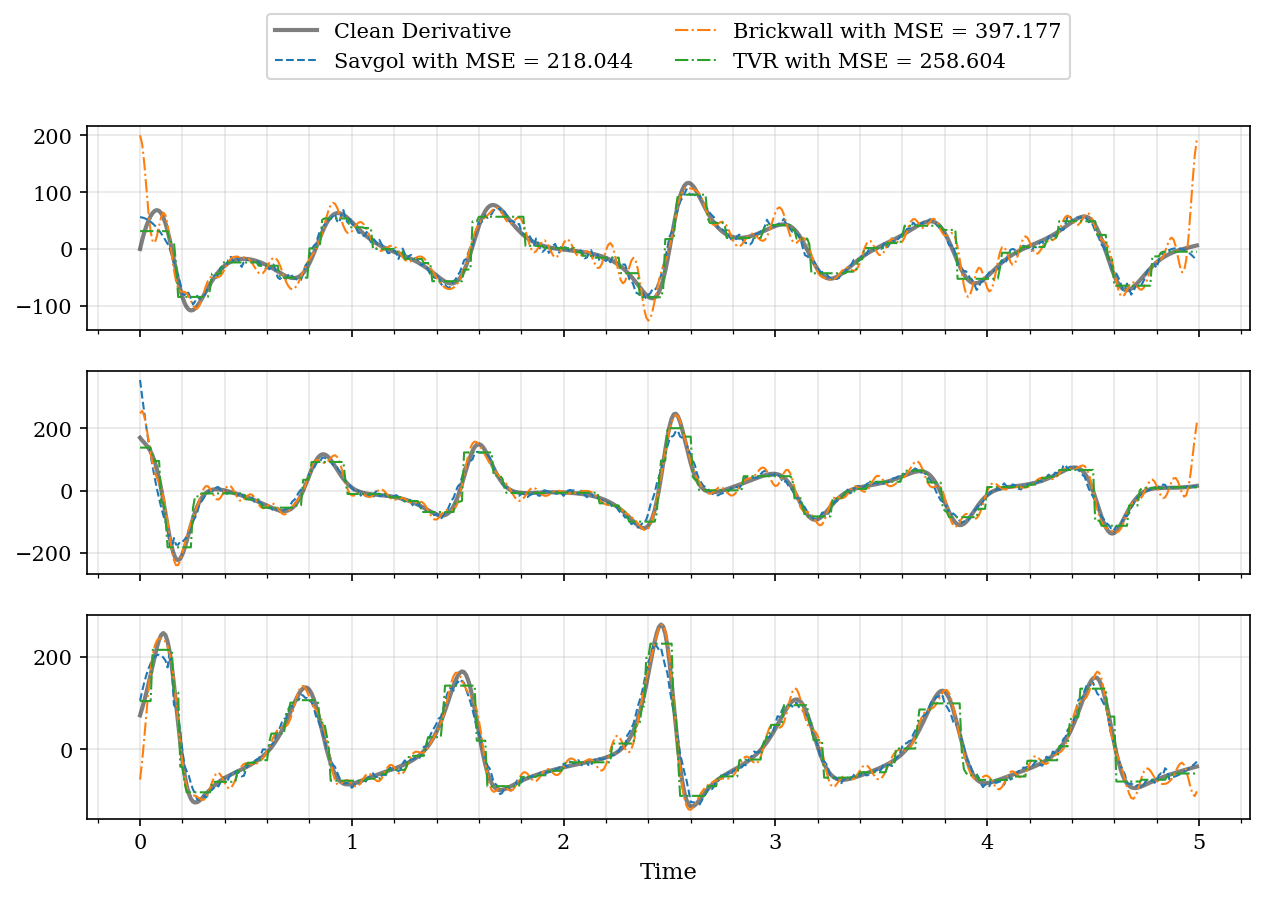

In [11]:
xdot_tvr = tvr(x_noisy, t, 0.001)
tvr_mse = np.mean((xdot_tvr - xdot)**2)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10,6))

for idx in range(3):

    axs[idx].plot(
        t, xdot[:,idx], 'k',
        label='Clean Derivative', alpha=0.5
    )
    axs[idx].plot(
        t, xdot_sg[:,idx], '--',
        label=f'Savgol with MSE = {sg_mse:.3f}', linewidth=1
    )
    axs[idx].plot(
        t, xdot_brick[:,idx], '-.',
        label=f'Brickwall with MSE = {brick_mse:.3f}', linewidth=1
    )
    axs[idx].plot(
        t, xdot_tvr[:,idx], '-.',
        label=f'TVR with MSE = {tvr_mse:.3f}', linewidth=1
    )
    
axs[-1].set_xlabel('Time')
axs[0].legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5,1.6));

Depending on the selected hyperparameters between methods, TVR should have comparable errors with other data smoothing methods. However, since it is an optimization formulation, the computational cost is higher than smoothing the data. The main advantage of using total variation regularized derivative is that it attenuates small variations but retains discontinuities within the dataset instead of smoothing it over. For example, let us look at the example of differentiating a RELU function which is defined as

$$ x(t) = max(0, t) $$

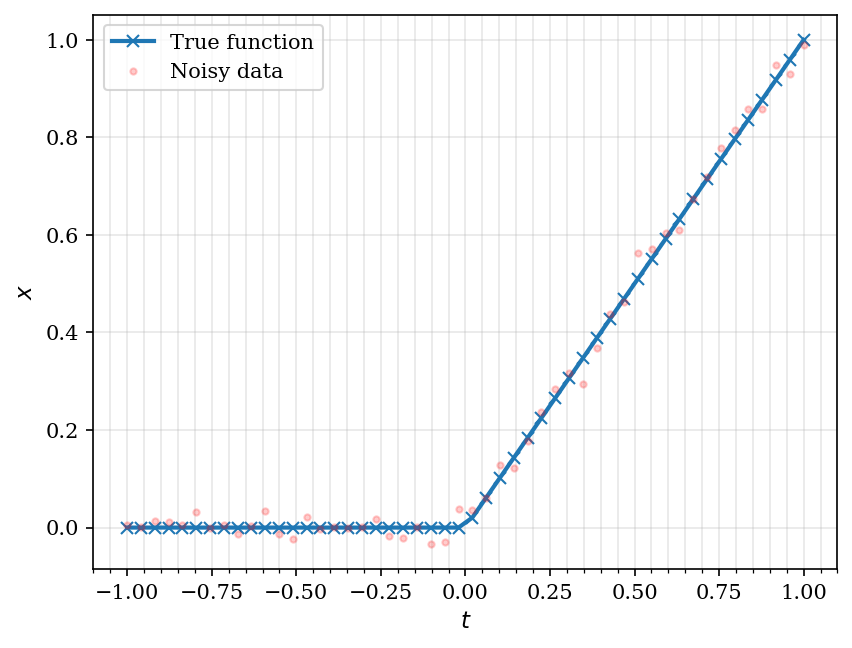

In [14]:
t = np.linspace(-1, 1)
x = np.maximum(0, t)
x_noisy = add_gauss_noise(x, noise_ratio)

plt.figure()
plt.plot(t, x, '-x', label='True function')
plt.plot(t, x_noisy, 'r.', alpha=0.2, label='Noisy data')
plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend();

From the comparison below, we can see that instead of smoothing over the discontinuity in the gradient, TVR differentiation captures the sharp discontinuity of the derivative.

/var/folders/j3/qn_kk08j1hqcw5jlph49xzch0000gp/T/ipykernel_44845/3818603155.py:86: UserWarning: Iteration limit exceeded for state 1.
  warnings.warn(f'Iteration limit exceeded for state {idx+1:d}.')


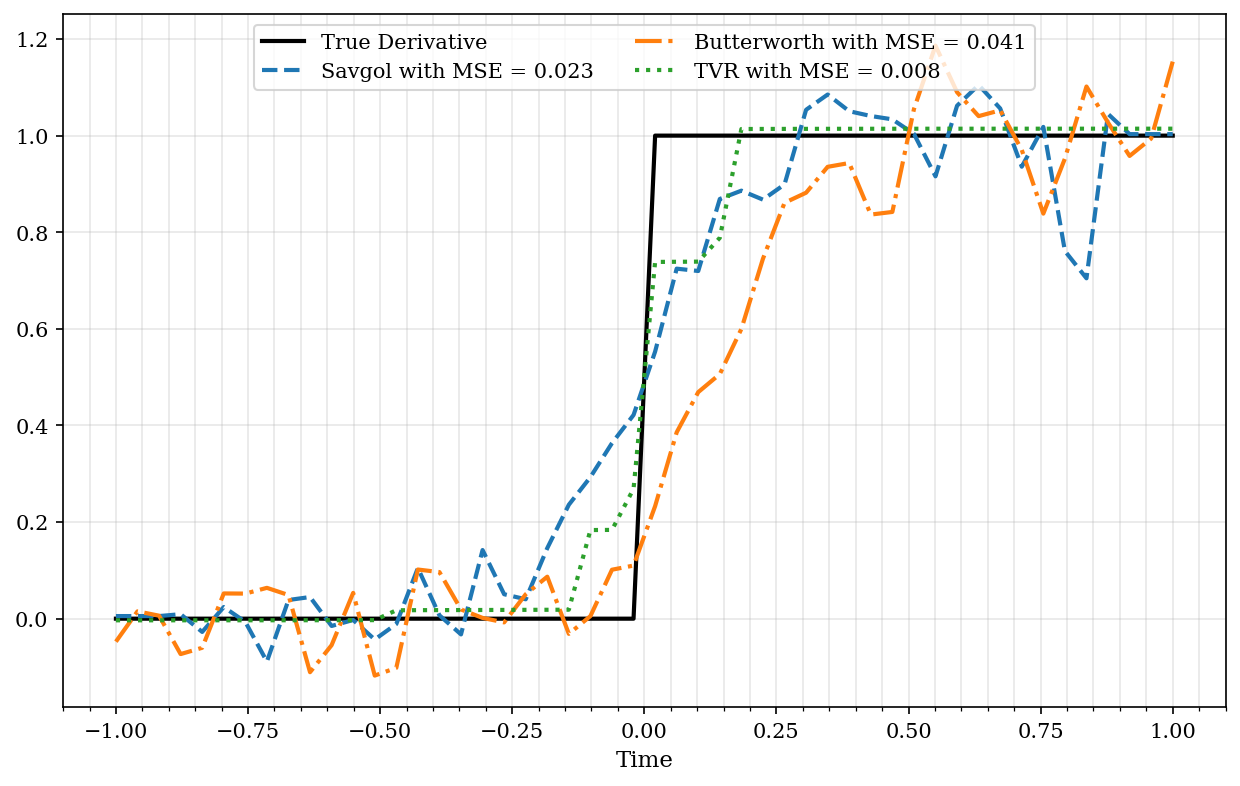

In [13]:
xdot_tvr = tvr(x_noisy, t, 0.0005).flatten()

x_smoothed_sg = signal.savgol_filter(x_noisy, 10, 1)
sos = signal.butter(1, 0.1, output='sos')
x_smoothed_but = signal.sosfilt(sos, x_noisy, axis=0)

xdot = np.maximum(0, t/abs(t))
xdot_sg = ps.FiniteDifference(4)._differentiate(x_smoothed_sg, t)
xdot_but = ps.FiniteDifference(4)._differentiate(x_smoothed_but, t)
 
sg_mse = np.mean((xdot_sg - xdot)**2)
but_mse = np.mean((xdot_but - xdot)**2)
tvr_mse = np.mean((xdot_tvr - xdot)**2)

plt.figure(figsize=(10,6))
plt.plot(t, xdot, 'k', label='True Derivative')
plt.plot(t, xdot_sg, '--', label=f'Savgol with MSE = {sg_mse:.3f}')
plt.plot(t, xdot_but, '-.', label=f'Butterworth with MSE = {but_mse:.3f}')
plt.plot(t, xdot_tvr, ':', label=f'TVR with MSE = {tvr_mse:.3f}')

plt.xlabel('Time')
plt.legend(loc='upper center', ncol=2);

When training on dataset with discontinuities, it is recommended to employ TVR differentiators, or even a hybrid approach which switches between finite difference and TVR differentiator for smooth and disjointed data respectively. However, strong regularization effects in TVR has induced a significant bias in the data (known as contrast loss).

For data with significant noise, the weak form of SINDy circumvents the requirement to numerically differentiate the data in the first place as we will see in later tutorials.